# Linear Regression (follow same build style as Logistic notebook)
This notebook reuses `get_clean_X_y()` from `data_utils` to load preprocessed data, performs nested stratified CV for unbiased evaluation while tuning regression-type models (LinearRegression, Ridge, Lasso, ElasticNet). Since the target is binary (0/1), predictions are thresholded at 0.5 for classification metrics in addition to regression metrics.

In [9]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
sns.set()

In [10]:
# Load cleaned data
from data_utils import get_clean_X_y
X, y = get_clean_X_y()
# Ensure target is numeric (0=edible, 1=poisonous)
if y.dtype == object or y.dtype.name == 'category':
    y = y.map({'e': 0, 'p': 1})
# If mapping produced NaN (different labels), try common conversions
if y.isnull().any():
    try:
        y = y.astype(float)
    except Exception:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y), index=y.index)

print('X shape:', X.shape)
print('y distribution:\n', y.value_counts())

X shape: (5644, 98)
y distribution:
 class
0    3488
1    2156
Name: count, dtype: int64


In [11]:
# Stratified train/test split (use same random_state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (4515, 98) Test shape: (1129, 98)


In [12]:
# Pipeline and parameter grid for different linear-type models
pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])

param_grid = [
    { 'model': [LinearRegression()], 'model__fit_intercept': [True, False] },
    { 'model': [Ridge()], 'model__alpha': [0.01, 0.1, 1, 10, 100] },
    { 'model': [Lasso()], 'model__alpha': [0.001, 0.01, 0.1, 1] },
    { 'model': [ElasticNet()], 'model__alpha': [0.001, 0.01, 0.1, 1], 'model__l1_ratio': [0.1, 0.5, 0.9] }
]

# Nested CV setup
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

print(f"Running nested CV (outer={outer_cv.get_n_splits()}, inner={inner_cv.get_n_splits()}) — this may take a while...")
nested_scores = cross_val_score(grid, X, y, cv=outer_cv, scoring='neg_mean_squared_error', n_jobs=-1)
# convert to positive MSE
nested_mse = -nested_scores
print('Nested CV MSE: mean={:.6f}, std={:.6f}'.format(nested_mse.mean(), nested_mse.std()))

# Refit on full data
print('Refitting GridSearchCV on full data...')
grid.fit(X, y)
print('Best params (full data):', grid.best_params_)
print('Best inner-CV score (neg MSE):', grid.best_score_)

best_reg = grid.best_estimator_
joblib.dump(best_reg, 'linear_best_model_nested.joblib')
print('Saved model to linear_best_model_nested.joblib')

Running nested CV (outer=5, inner=5) — this may take a while...


Nested CV MSE: mean=0.000000, std=0.000000
Refitting GridSearchCV on full data...
Fitting 5 folds for each of 23 candidates, totalling 115 fits
Best params (full data): {'model': LinearRegression(), 'model__fit_intercept': True}
Best inner-CV score (neg MSE): -3.1952180951341796e-30
Saved model to linear_best_model_nested.joblib


MSE: 0.000000, RMSE: 0.000000, R2: 1.000000
Classification accuracy (threshold=0.5): 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       698
           1       1.00      1.00      1.00       431

    accuracy                           1.00      1129
   macro avg       1.00      1.00      1.00      1129
weighted avg       1.00      1.00      1.00      1129



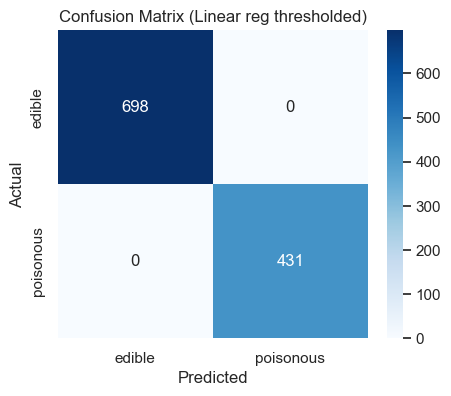

In [13]:
# Evaluate best regressor on held-out test set
y_pred_cont = best_reg.predict(X_test)
# Regression metrics
mse = mean_squared_error(y_test, y_pred_cont)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_cont)
print(f'MSE: {mse:.6f}, RMSE: {rmse:.6f}, R2: {r2:.6f}')

# Threshold predictions for classification evaluation
y_pred_class = (y_pred_cont >= 0.5).astype(int)
print('Classification accuracy (threshold=0.5):', accuracy_score(y_test, y_pred_class))
print('\nClassification report:\n', classification_report(y_test, y_pred_class))
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['edible','poisonous'], yticklabels=['edible','poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Linear reg thresholded)')
plt.show()